In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")



In [2]:
df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")

In [3]:
print("Размер датасета:", df.shape)
display(df.head())

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isna().sum())

print("\nДубликаты:", df.duplicated().sum())

print("\nСтатистики:")
display(df.describe(include="all"))

Размер датасета: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Типы данных:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Пропуски:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Дубликаты: 0

Статистики:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


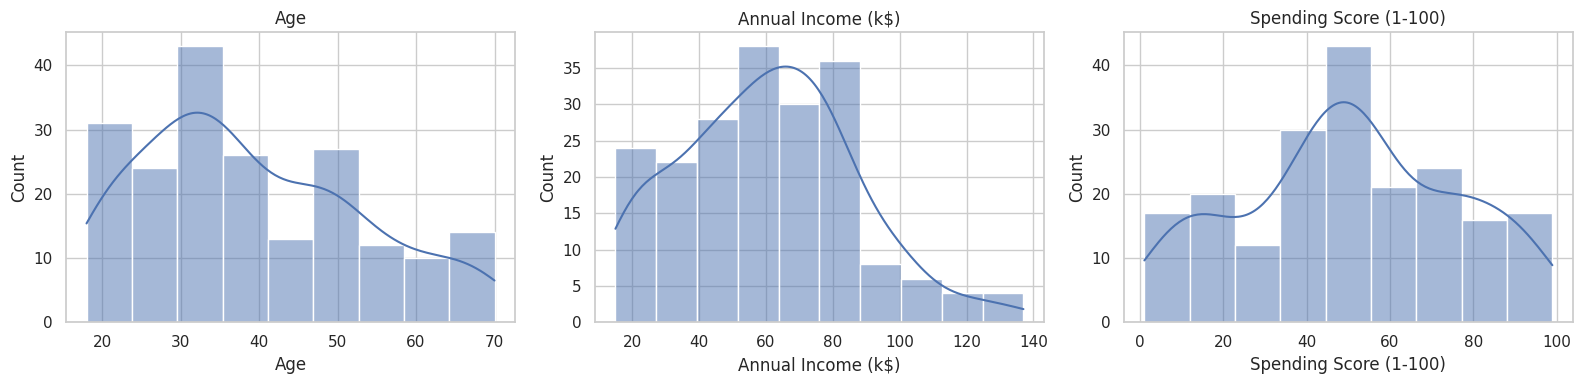

In [4]:
numeric = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [5]:
outlier_rows = []

for col in numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": mask.sum(),
        "Outliers (%)": mask.mean() * 100
    })

outlier_table = pd.DataFrame(outlier_rows)

display(outlier_table.round(2))

,Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outliers (%)
0,Age,28.75,49.0,20.25,-1.62,79.38,0,0.0
1,Annual Income (k$),41.50,78.0,36.50,-13.25,132.75,2,1.0
2,Spending Score (1-100),34.75,73.0,38.25,-22.62,130.38,0,0.0


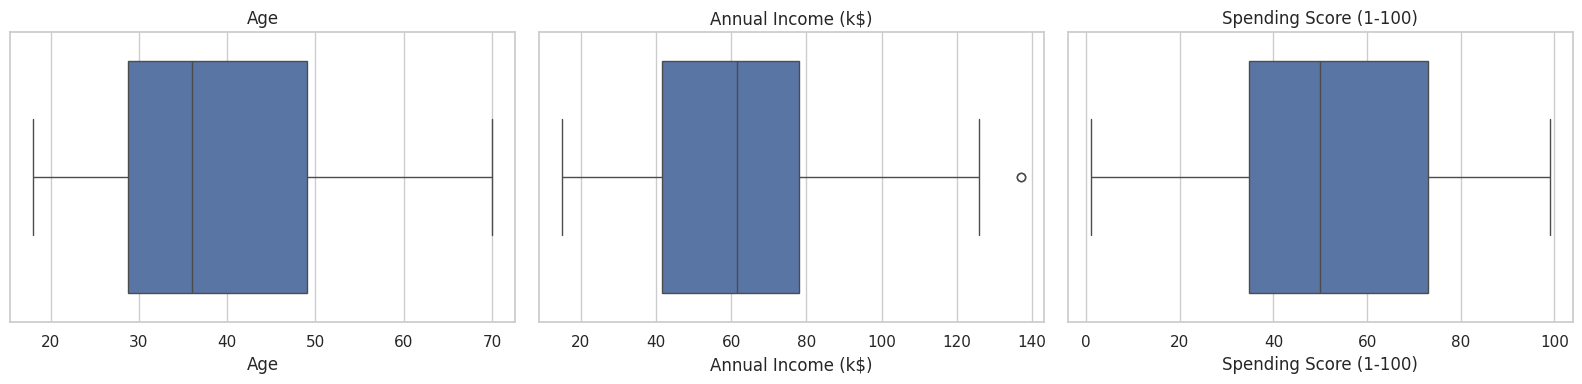

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Выбросов вроде почти нет.

Gender
Female    112
Male       88
Name: count, dtype: int64


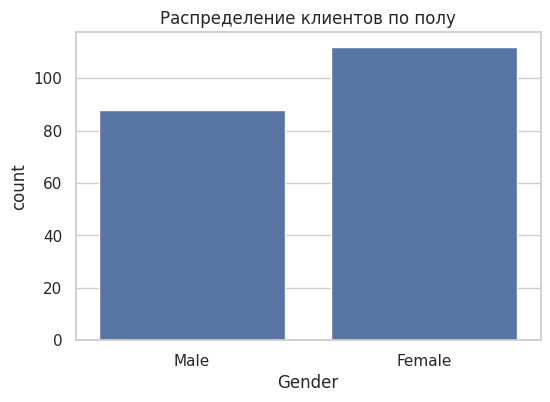

In [7]:
print(df["Gender"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender")
plt.title("Распределение клиентов по полу")
plt.show()

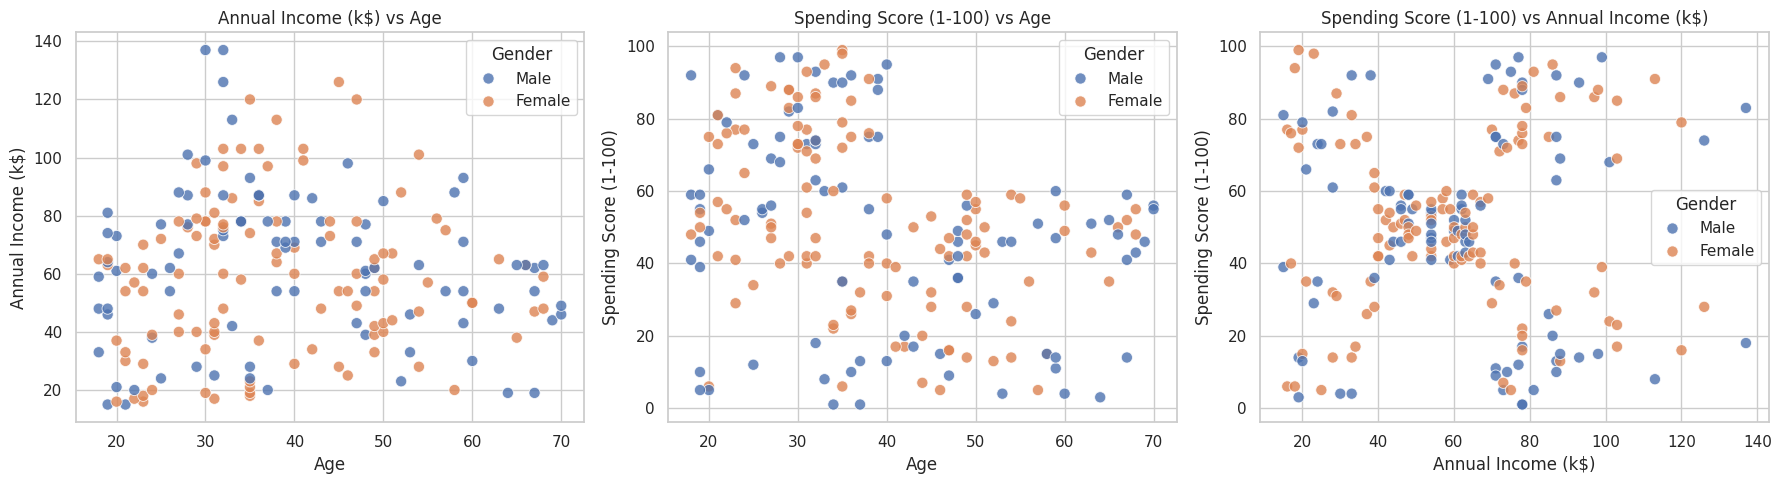

In [8]:
pairs = [
    ("Age", "Annual Income (k$)"),
    ("Age", "Spending Score (1-100)"),
    ("Annual Income (k$)", "Spending Score (1-100)")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="Gender",
        s=65,
        alpha=0.8,
        ax=ax
    )
    ax.set_title(f"{y_col} vs {x_col}")

plt.tight_layout()
plt.show()

Уже видны кластеры. Также видно, что гендер не влияет.

In [9]:
X = df[numeric].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=numeric,
    index=df.index
)

,Before scaling,After scaling
Mean distance,50.551,2.263
Median distance,49.548,2.246
Std distance,23.415,0.953


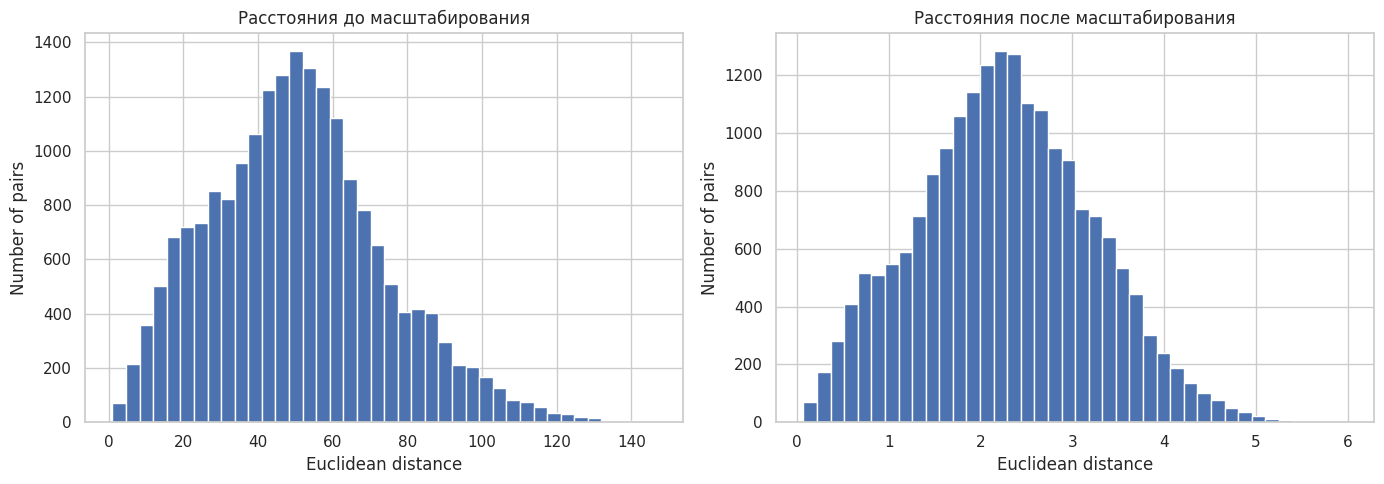

In [10]:
dist_before = pairwise_distances(X)
dist_after = pairwise_distances(X_scaled)

upper_triangle = np.triu_indices_from(
    dist_before,
    k=1
)

distance_summary = pd.DataFrame({
    "Before scaling": [
        dist_before[upper_triangle].mean(),
        np.median(dist_before[upper_triangle]),
        dist_before[upper_triangle].std()
    ],
    "After scaling": [
        dist_after[upper_triangle].mean(),
        np.median(dist_after[upper_triangle]),
        dist_after[upper_triangle].std()
    ]
}, index=[
    "Mean distance",
    "Median distance",
    "Std distance"
])

display(distance_summary.round(3))


# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    dist_before[upper_triangle],
    bins=40
)
axes[0].set_title("Расстояния до масштабирования")
axes[0].set_xlabel("Euclidean distance")
axes[0].set_ylabel("Number of pairs")

axes[1].hist(
    dist_after[upper_triangle],
    bins=40
)
axes[1].set_title("Расстояния после масштабирования")
axes[1].set_xlabel("Euclidean distance")
axes[1].set_ylabel("Number of pairs")

plt.tight_layout()
plt.show()

In [11]:
k_values = range(2, 11)

kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "Calinski-Harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        ),
        "Davies-Bouldin": davies_bouldin_score(
            X_scaled,
            labels
        )
    })

kmeans_results = pd.DataFrame(kmeans_results)

kmeans_results["Silhouette rank"] = (
    kmeans_results["Silhouette"]
    .rank(ascending=False)
)

kmeans_results["Calinski rank"] = (
    kmeans_results["Calinski-Harabasz"]
    .rank(ascending=False)
)

kmeans_results["Davies rank"] = (
    kmeans_results["Davies-Bouldin"]
    .rank(ascending=True)
)

kmeans_results["Mean metric rank"] = (
    kmeans_results[
        [
            "Silhouette rank",
            "Calinski rank",
            "Davies rank"
        ]
    ]
    .mean(axis=1)
)

display(kmeans_results.round(4))

,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Silhouette rank,Calinski rank,Davies rank,Mean metric rank
0,2,389.3862,0.3355,107.0956,1.2607,9.0,8.0,9.0,8.6667
1,3,295.2122,0.3578,101.6949,1.0503,8.0,9.0,8.0,8.3333
2,4,205.2251,0.4040,125.6764,0.9308,6.0,6.0,7.0,6.3333
3,5,168.2476,0.4166,125.1009,0.8746,4.0,7.0,4.0,5.0000
4,6,133.8683,0.4274,135.1022,0.8277,1.0,1.0,2.0,1.3333
5,7,117.0116,0.4172,132.7743,0.7935,3.0,3.0,1.0,2.3333
6,8,103.8286,0.4087,131.0744,0.8893,5.0,5.0,5.0,5.0000
7,9,92.3495,0.4201,131.2423,0.8541,2.0,4.0,3.0,3.0000
8,10,81.9871,0.3973,133.3848,0.9056,7.0,2.0,6.0,5.0000


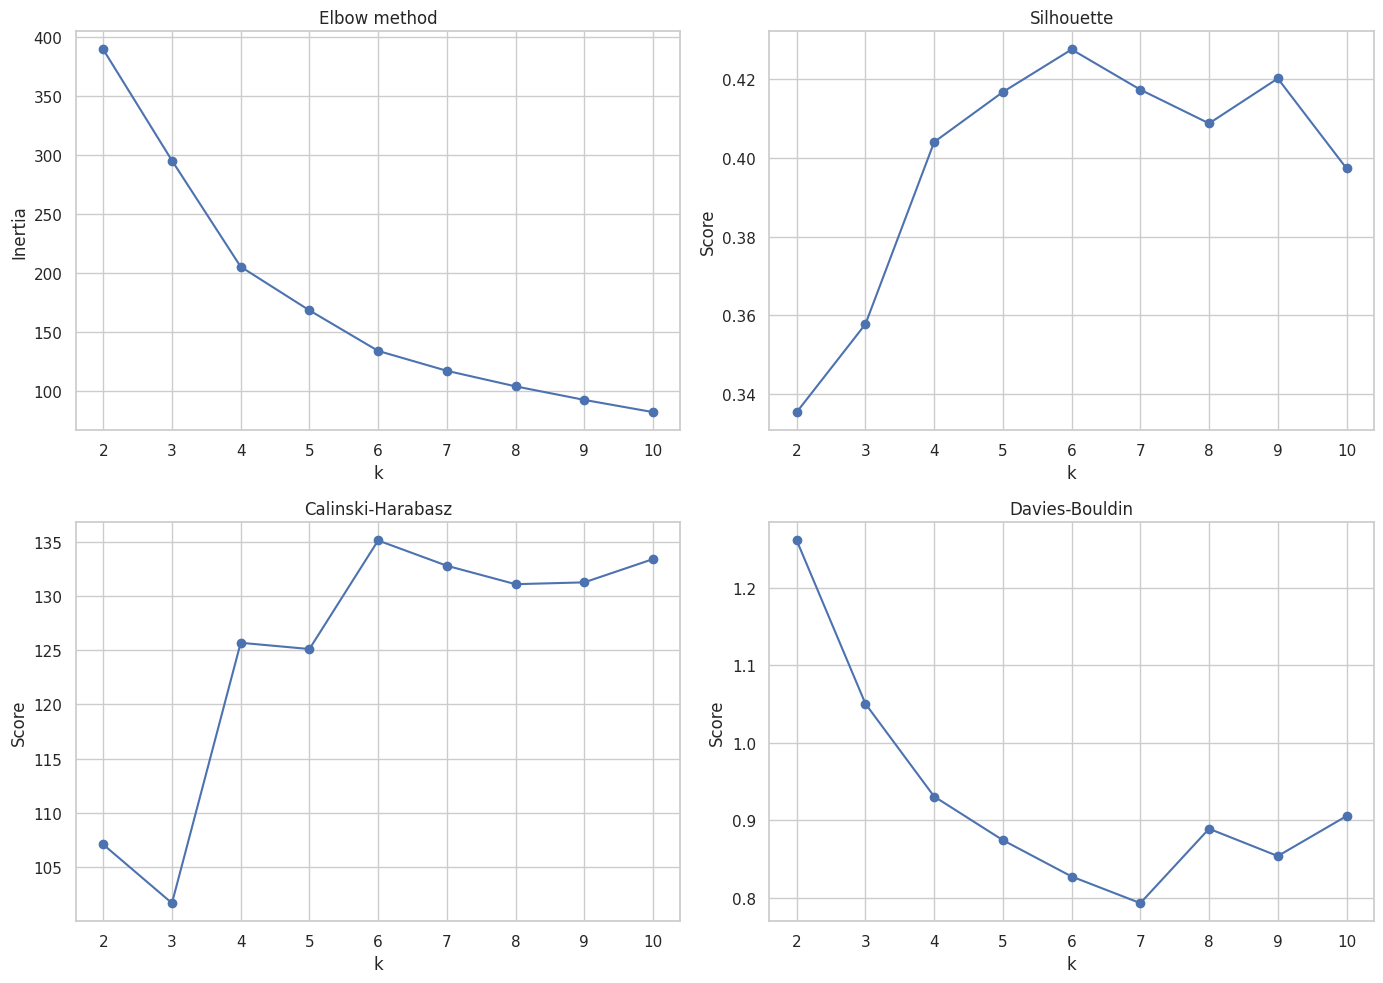

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    kmeans_results["k"],
    kmeans_results["Inertia"],
    marker="o"
)
axes[0, 0].set_title("Elbow method")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_xticks(k_values)

axes[0, 1].plot(
    kmeans_results["k"],
    kmeans_results["Silhouette"],
    marker="o"
)
axes[0, 1].set_title("Silhouette")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_xticks(k_values)

axes[1, 0].plot(
    kmeans_results["k"],
    kmeans_results["Calinski-Harabasz"],
    marker="o"
)
axes[1, 0].set_title("Calinski-Harabasz")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_xticks(k_values)

axes[1, 1].plot(
    kmeans_results["k"],
    kmeans_results["Davies-Bouldin"],
    marker="o"
)
axes[1, 1].set_title("Davies-Bouldin")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_xticks(k_values)

plt.tight_layout()
plt.show()

На удивление похожий паттерн для всех трех метрик. (Если учесть, что Davies-Bouldin работает "перевернуто", т.е. меньше - лучше). Best K выбираем 6.

In [13]:
BEST_K = 6

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_cluster"] = kmeans_labels

print("Выбранное k:", BEST_K)
print("Размеры кластеров:")
display(
    df["KMeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

Выбранное k: 6
Размеры кластеров:


,Count
KMeans_cluster,
0,33
1,45
2,24
3,39
4,38
5,21


In [14]:
kmeans_profile = (
    df.groupby("KMeans_cluster")[numeric]
    .agg(["mean", "median"])
    .round(2)
)

display(kmeans_profile)


# %%
kmeans_sizes = (
    df["KMeans_cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile = (
    df.groupby("KMeans_cluster")[numeric]
    .mean()
)

cluster_profile["Size"] = kmeans_sizes

display(cluster_profile.round(2))

Age        Annual Income (k$)        Spending Score (1-100)  \
                 mean median               mean median                   mean   
KMeans_cluster                                                                  
0               41.94   43.0              88.94   86.0                  16.97   
1               56.33   54.0              54.27   54.0                  49.07   
2               25.25   23.5              25.83   24.5                  76.92   
3               32.69   32.0              86.54   79.0                  82.13   
4               26.68   26.0              57.58   60.0                  47.79   
5               45.52   46.0              26.29   25.0                  19.38   

                       
               median  
KMeans_cluster         
0                16.0  
1                49.0  
2                76.5  
3                83.0  
4                49.5  
5                15.0

,Age,Annual Income (k$),Spending Score (1-100),Size
KMeans_cluster,,,,
0,41.94,88.94,16.97,33
1,56.33,54.27,49.07,45
2,25.25,25.83,76.92,24
3,32.69,86.54,82.13,39
4,26.68,57.58,47.79,38
5,45.52,26.29,19.38,21


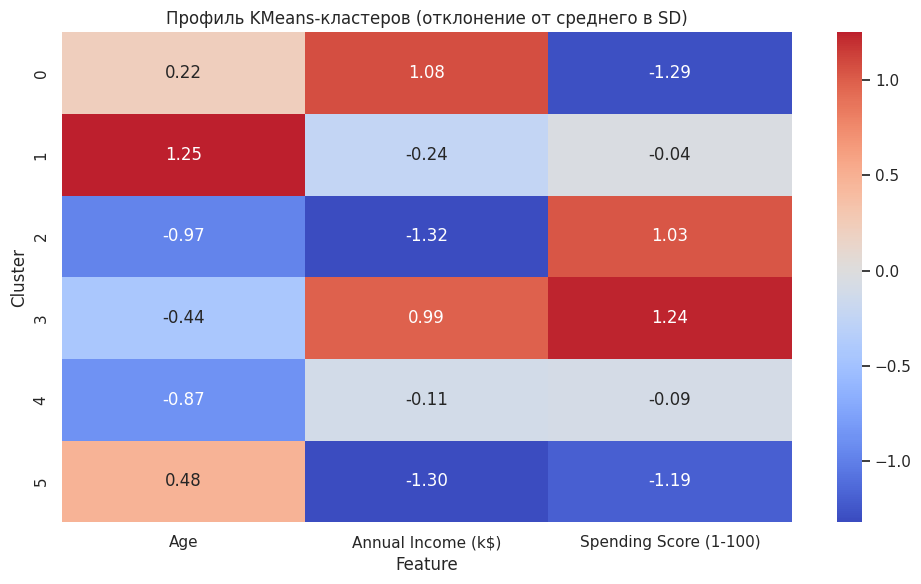

In [15]:
cluster_zprofile = (
    cluster_profile[numeric] - df[numeric].mean()
) / df[numeric].std()

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_zprofile,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title(
    "Профиль KMeans-кластеров "
    "(отклонение от среднего в SD)"
)
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

Gender,Female,Male
KMeans_cluster,,
0,42.4,57.6
1,57.8,42.2
2,58.3,41.7
3,53.8,46.2
4,63.2,36.8
5,61.9,38.1


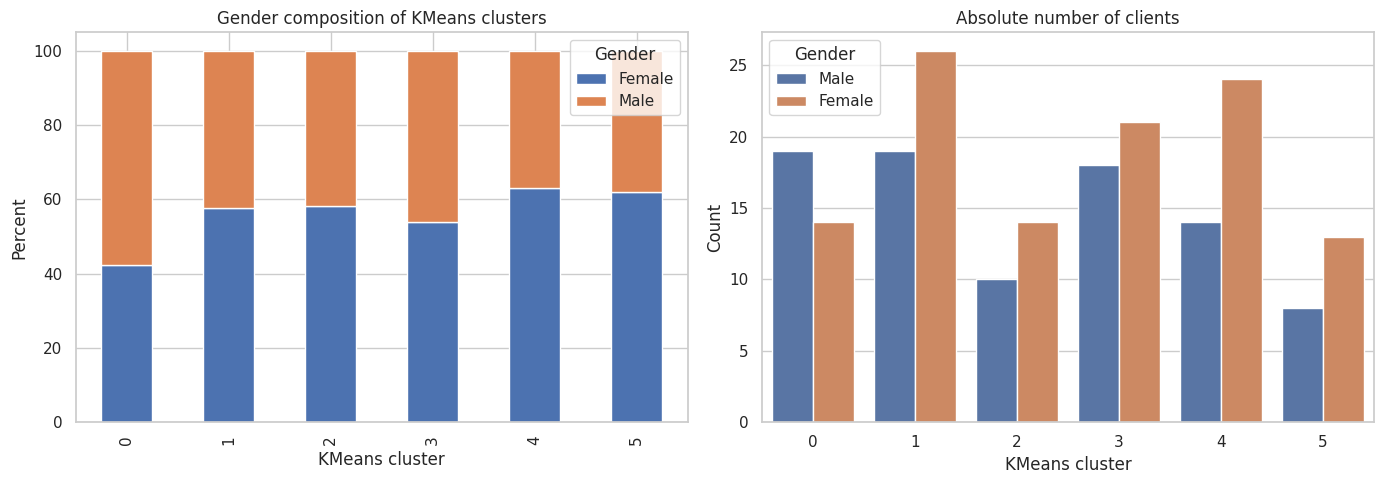

In [16]:
kmeans_gender = pd.crosstab(
    df["KMeans_cluster"],
    df["Gender"],
    normalize="index"
) * 100

display(kmeans_gender.round(1))


# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kmeans_gender.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Gender composition of KMeans clusters")
axes[0].set_xlabel("KMeans cluster")
axes[0].set_ylabel("Percent")
axes[0].legend(title="Gender")


sns.countplot(
    data=df,
    x="KMeans_cluster",
    hue="Gender",
    ax=axes[1]
)

axes[1].set_title("Absolute number of clients")
axes[1].set_xlabel("KMeans cluster")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

И снова гендер почти не имеет значения. 

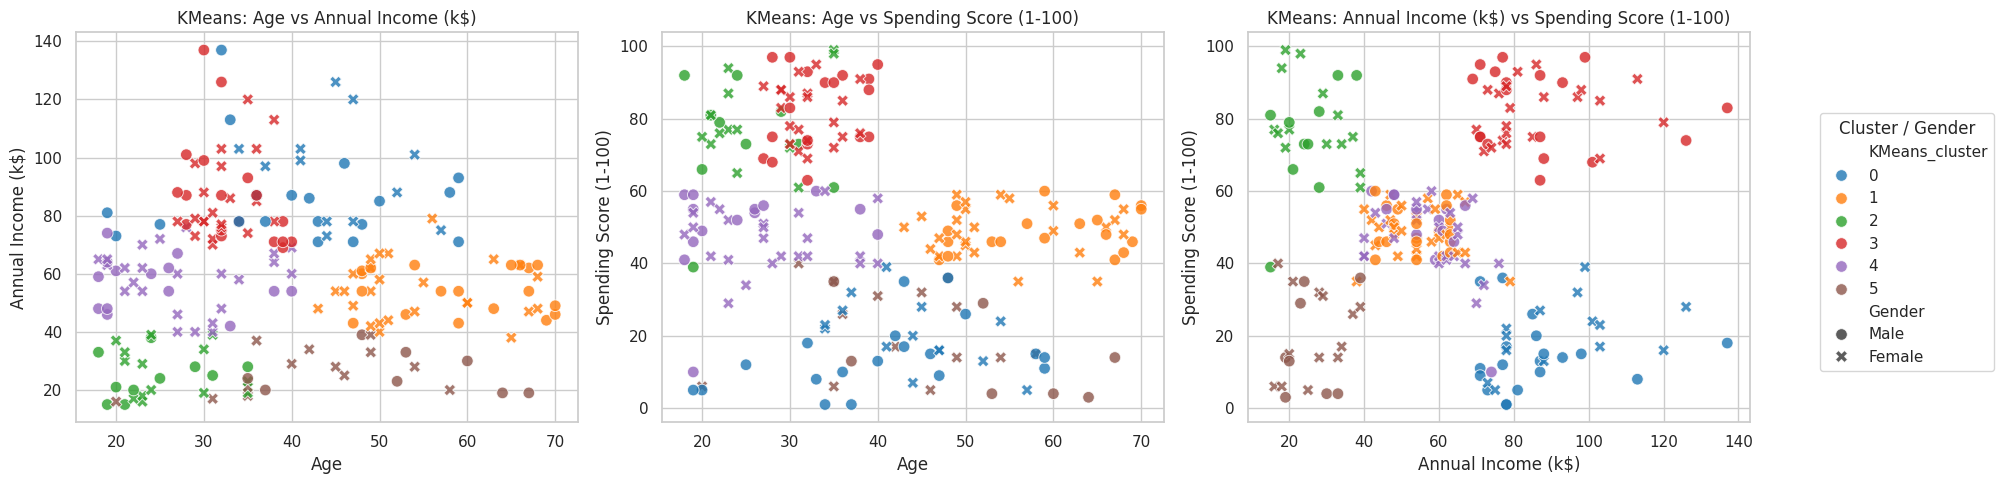

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (ax, (x_col, y_col)) in enumerate(zip(axes, pairs)):
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="KMeans_cluster",
        style="Gender",
        palette="tab10",
        s=70,
        alpha=0.8,
        ax=ax,
        legend=(i == 0)
    )

    ax.set_title(f"KMeans: {x_col} vs {y_col}")

# Оставляем легенду только у первого графика
handles, labels = axes[0].get_legend_handles_labels()

axes[0].legend_.remove()

fig.legend(
    handles,
    labels,
    title="Cluster / Gender",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

Как мы видим, адекватнее всего группируются Annual income vs Spending score. Что логично. Интересна группа с низким доходом и высокими затратами (левый верхний угол). Возможно, это люди, которые закупаются сразу на неделю, чтобы экономить оптом. Также интересна симметрия: оба кластера людей с низким доходом и оба кластера людей с высоким доходом очень похожи по форме.

Интересно, что на осях spending score vs annual income желтый и фиолетовый кластеры не разделяются. На самом деле, если выбрать BEST_K = 5, они превращаются в один кластер. Я назвала его "нормисы". Но при этом они очень хорошо разделяются по возрасту. Для магазина это может не иметь особого значения, т.к. платят эти два класса одинаково.

Теперь пробуем DBScan с разными параметрами.

In [18]:
# Сначала перебираем `eps` и `min_samples`.
# Для каждого варианта считаем:
# - число кластеров;
# - долю шума;
# - Silhouette;
# - Calinski-Harabasz;
# - Davies-Bouldin.
#
# Метрики считаются только по объектам, которые DBSCAN не пометил как шум.


# %%
eps_values = np.round(
    np.arange(0.20, 1.01, 0.05),
    2
)

min_samples_values = list(range(4, 15))

dbscan_results = []

for min_samples in min_samples_values:

    for eps in eps_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        noise_mask = labels == -1
        non_noise_mask = ~noise_mask

        n_clusters = len(
            set(labels) - {-1}
        )

        noise_fraction = noise_mask.mean() * 100

        silhouette = np.nan
        calinski = np.nan
        davies = np.nan

        if (
            n_clusters >= 2
            and non_noise_mask.sum() > n_clusters
        ):
            X_eval = X_scaled[non_noise_mask]
            y_eval = labels[non_noise_mask]

            silhouette = silhouette_score(
                X_eval,
                y_eval
            )

            calinski = calinski_harabasz_score(
                X_eval,
                y_eval
            )

            davies = davies_bouldin_score(
                X_eval,
                y_eval
            )

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_%": noise_fraction,
            "Silhouette": silhouette,
            "Calinski-Harabasz": calinski,
            "Davies-Bouldin": davies
        })

dbscan_results = pd.DataFrame(dbscan_results)

In [19]:
# ### Только варианты, подходящие для интерпретации
#
# Исключаем варианты:
# - с одним кластером;
# - без возможности посчитать метрики;
# - с очень большой долей шума.
#
# Порог `noise_% <= 20` здесь является фильтром для просмотра,
# а не отдельной метрикой качества.


# %%
dbscan_candidates = dbscan_results[
    (dbscan_results["n_clusters"] >= 2) &
    (dbscan_results["noise_%"] <= 20) &
    (dbscan_results["Silhouette"].notna())
].copy()

dbscan_candidates["Silhouette rank"] = (
    dbscan_candidates["Silhouette"]
    .rank(ascending=False)
)

dbscan_candidates["Calinski rank"] = (
    dbscan_candidates["Calinski-Harabasz"]
    .rank(ascending=False)
)

dbscan_candidates["Davies rank"] = (
    dbscan_candidates["Davies-Bouldin"]
    .rank(ascending=True)
)

dbscan_candidates["Mean metric rank"] = (
    dbscan_candidates[
        [
            "Silhouette rank",
            "Calinski rank",
            "Davies rank"
        ]
    ]
    .mean(axis=1)
)

display(
    dbscan_candidates
    .sort_values(
        ["Mean metric rank", "noise_%"]
    )
    .round(4)
)

,eps,min_samples,n_clusters,noise_%,Silhouette,Calinski-Harabasz,Davies-Bouldin,Silhouette rank,Calinski rank,Davies rank,Mean metric rank
6,0.50,4,8,19.5,0.2815,35.1914,0.8918,1.0,4.0,3.0,2.6667
25,0.60,5,2,14.0,0.2730,54.4214,1.0204,2.0,2.0,11.0,5.0000
26,0.65,5,2,10.5,0.2646,54.9200,1.0328,3.0,1.0,12.0,5.3333
8,0.60,4,3,9.0,0.2015,32.6472,0.9460,9.0,5.0,4.0,6.0000
24,0.55,5,4,19.5,0.2336,37.0913,0.9697,7.0,3.0,10.0,6.6667
147,0.75,12,2,19.0,0.2488,31.2334,0.9660,4.5,7.5,8.5,6.8333
164,0.75,13,2,19.0,0.2488,31.2334,0.9660,4.5,7.5,8.5,6.8333
9,0.65,4,3,7.0,0.1950,32.4649,0.9466,10.0,6.0,5.0,7.0000
61,0.70,7,2,11.0,0.2145,9.4876,0.7449,8.0,13.0,1.0,7.3333
182,0.80,14,2,18.5,0.2377,28.8382,0.9649,6.0,10.0,7.0,7.6667


Этот тупой кусок говна залагал и не сохранил еще час моей работы. Переделывать это нормально я не буду. Что есть, то есть.

eps: 0.5
min_samples: 4
Количество кластеров: 8
Количество шумовых объектов: 39
Доля шума: 19.5 %


,Metric,Value
0,Silhouette,0.2815
1,Calinski-Harabasz,35.1914
2,Davies-Bouldin,0.8918


Age        Annual Income (k$)        Spending Score (1-100)  \
                 mean median               mean median                   mean   
DBSCAN_cluster                                                                  
0               23.78   23.0              26.56   26.5                  77.44   
1               37.00   35.5              26.00   26.0                  33.17   
2               53.50   53.5              28.50   30.5                  11.75   
3               42.65   47.0              54.92   54.0                  48.75   
4               32.88   32.0              82.00   78.0                  83.24   
5               20.75   19.5              76.25   75.5                   8.00   
6               42.88   43.5              79.75   78.0                  14.00   
7               37.00   36.5              96.50   98.0                  30.25   

                       
               median  
DBSCAN_cluster         
0                76.5  
1                33.5  
2                14.0  
3                49.0  
4                86.0  
5                 7.5  
6                14.5  
7                29.5

,Count
DBSCAN_cluster,
-1,39
0,18
1,6
2,4
3,83
4,34
5,4
6,8
7,4


Gender,Female,Male
DBSCAN_cluster,,
-1,48.7,51.3
0,55.6,44.4
1,83.3,16.7
2,75.0,25.0
3,59.0,41.0
4,55.9,44.1
5,0.0,100.0
6,37.5,62.5
7,100.0,0.0


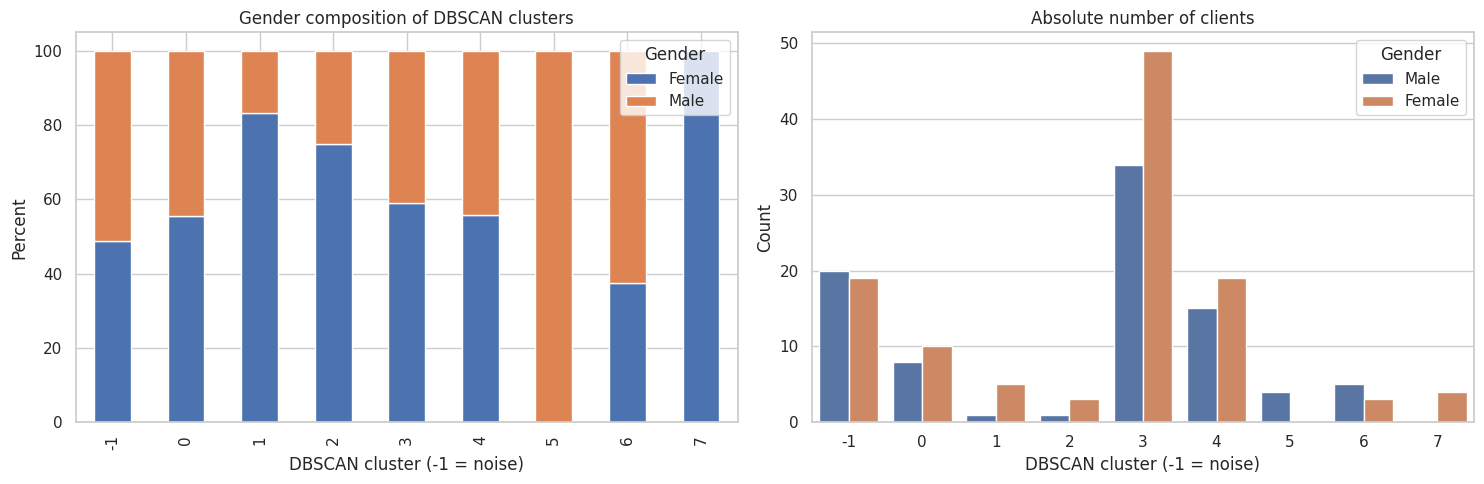

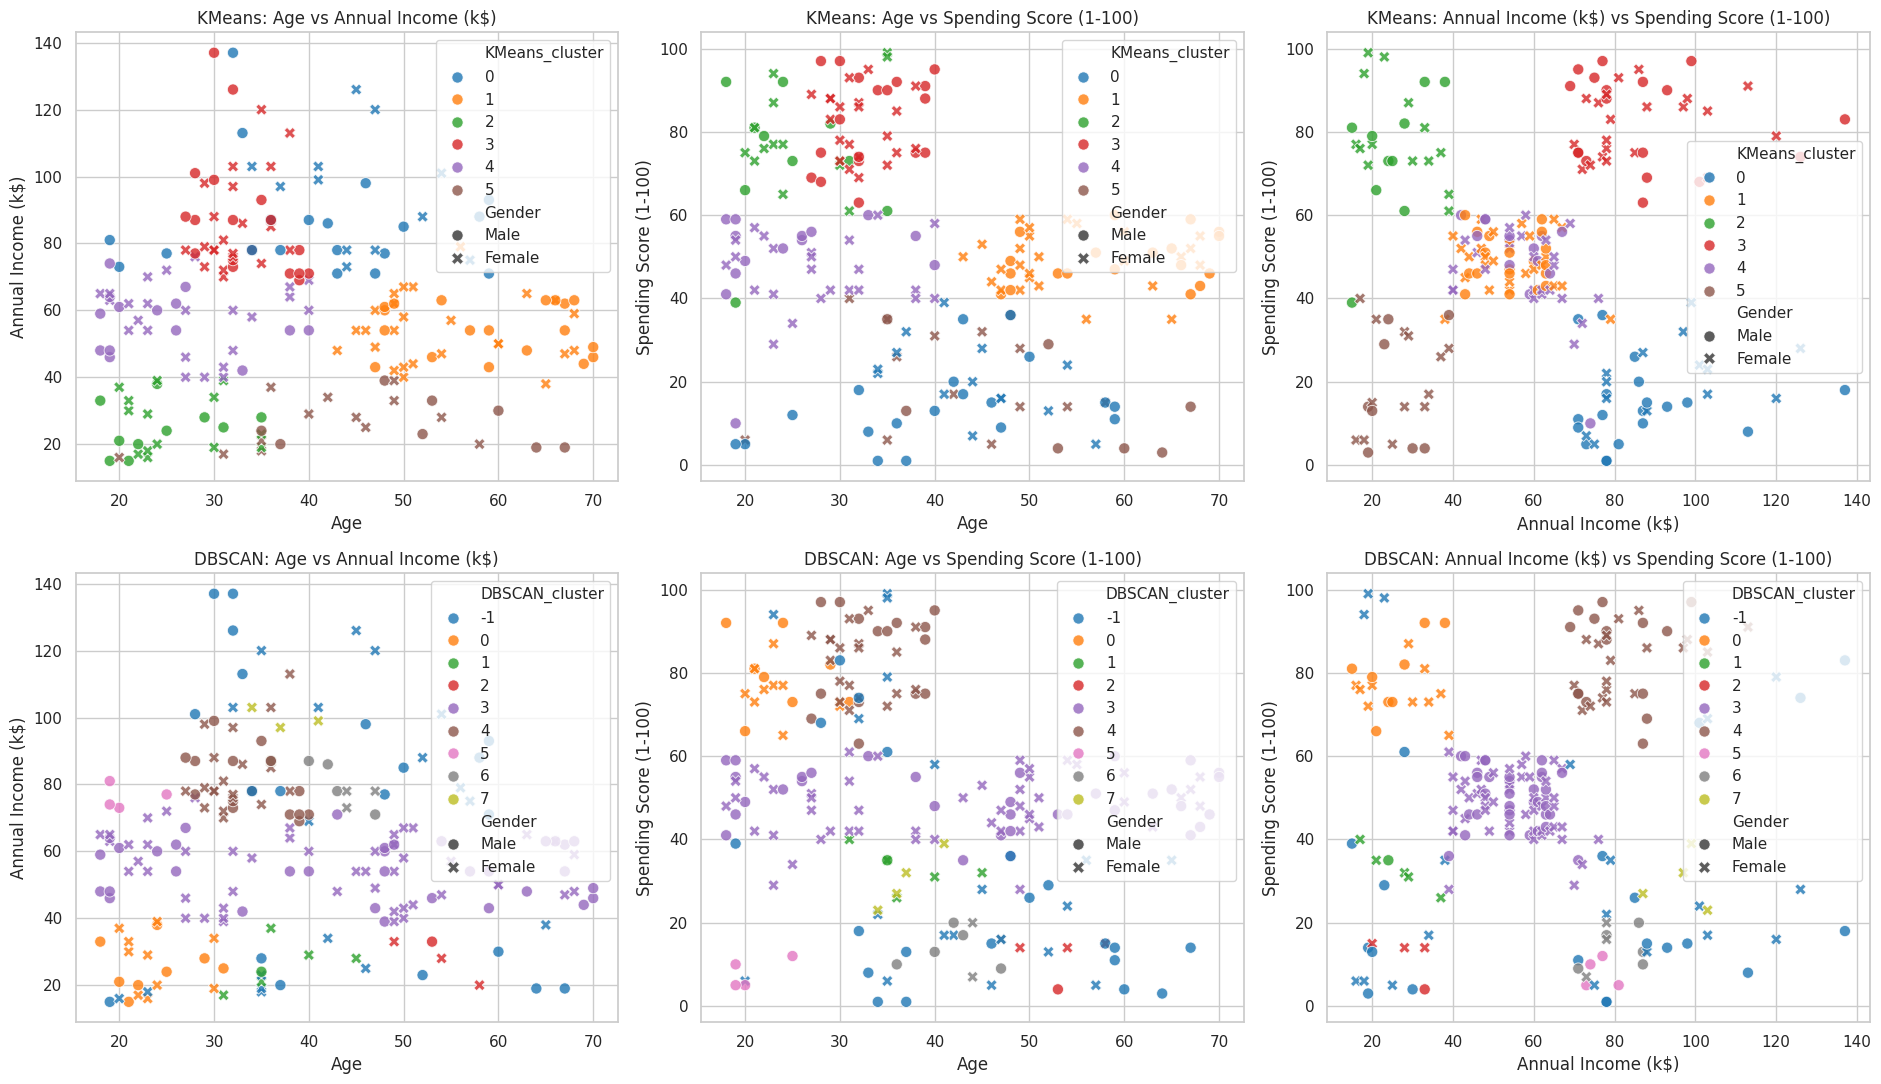

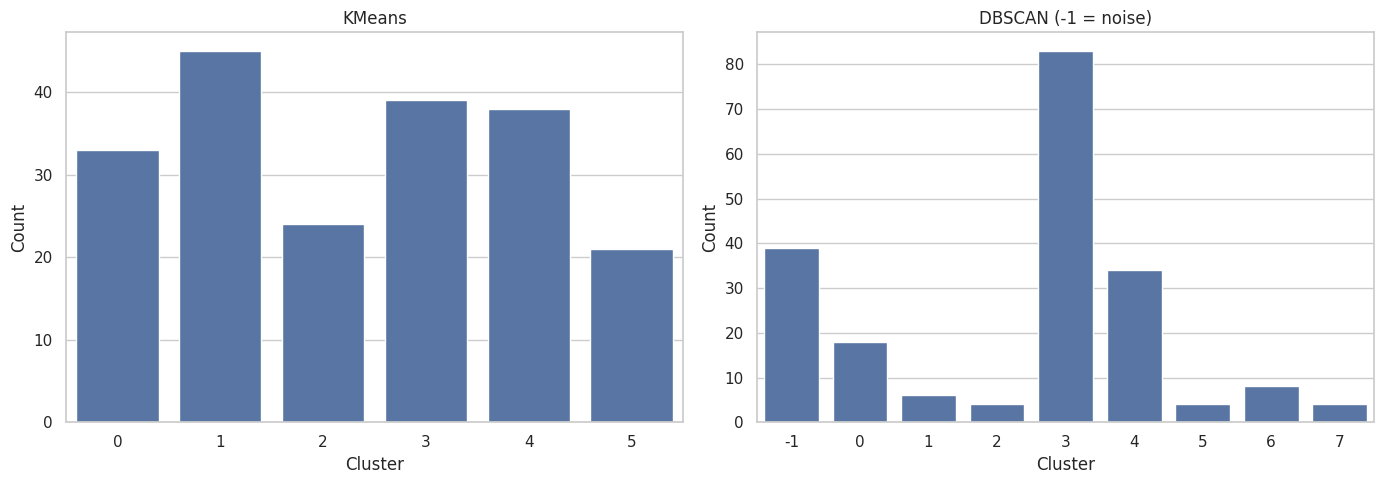

,Component,Explained variance,Cumulative variance
0,1,0.4427,0.4427
1,2,0.3331,0.7757
2,3,0.2243,1.0000


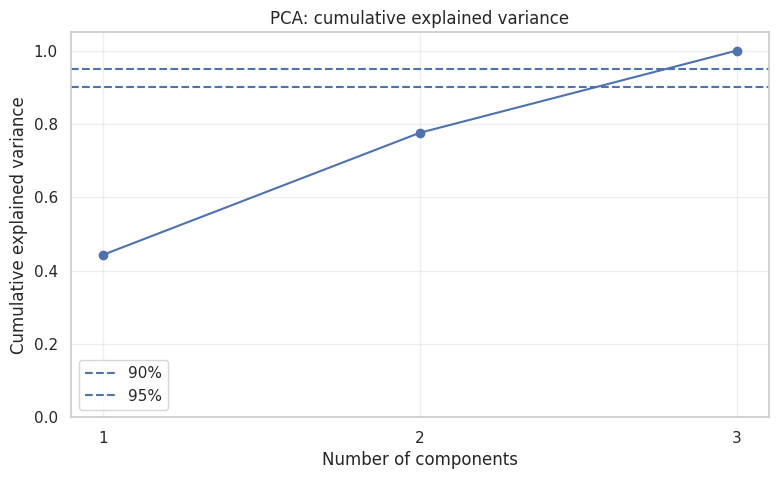

,PC1,PC2
Age,0.7064,0.0301
Annual Income (k$),-0.0480,0.9988
Spending Score (1-100),-0.7062,-0.0378


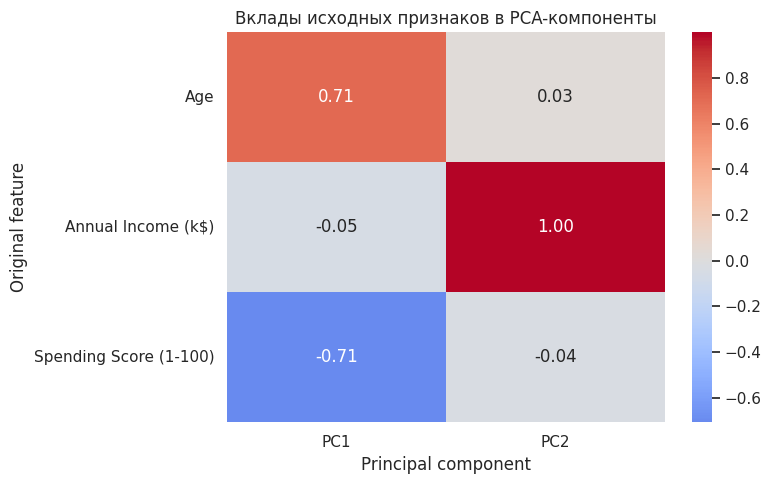


PC1:


,PC1
Age,0.7064
Spending Score (1-100),-0.7062
Annual Income (k$),-0.0480



PC2:


,PC2
Annual Income (k$),0.9988
Spending Score (1-100),-0.0378
Age,0.0301


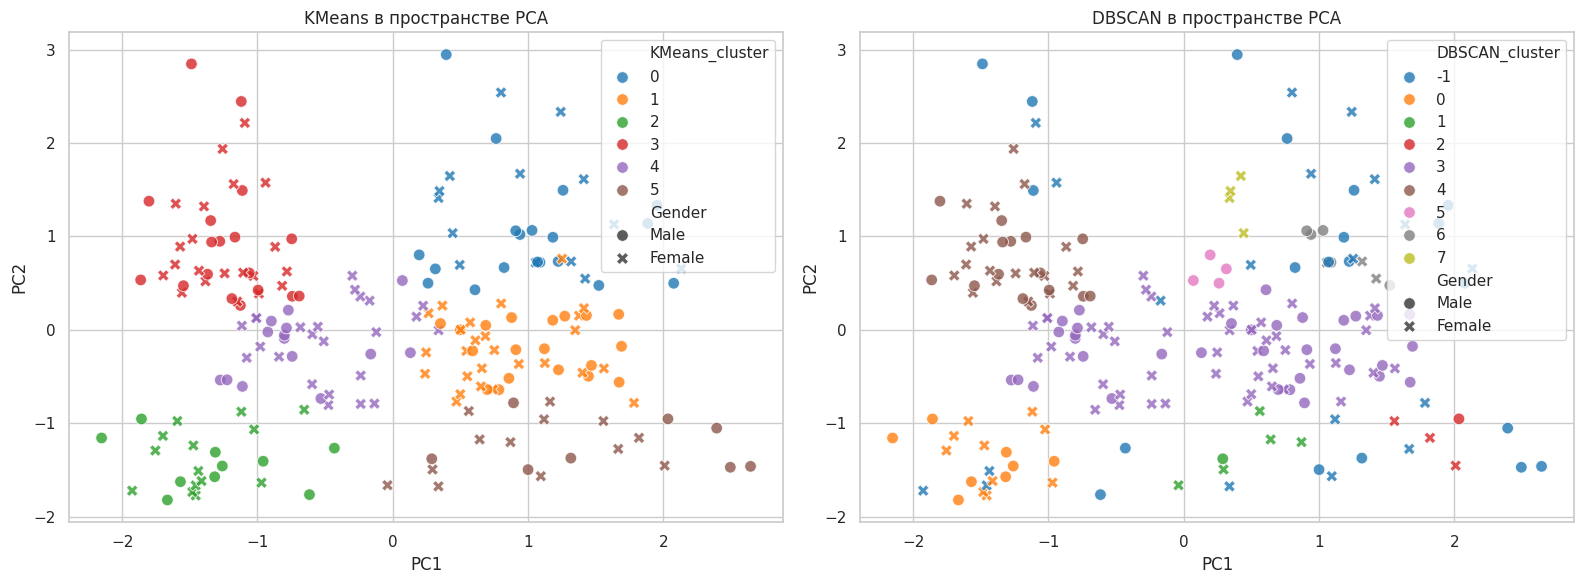

,Algorithm,Clusters,Noise %,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,6,NaN,0.4274,135.1022,0.8277
1,DBSCAN,8,19.5,0.2815,35.1914,0.8918


,Component,Explained variance (%)
0,PC1,44.27
1,PC2,33.31
2,PC1 + PC2,77.57


=== KMeans ===

Размеры кластеров:


,Count
KMeans_cluster,
0,33
1,45
2,24
3,39
4,38
5,21



Средние значения:


...

,Count
DBSCAN_cluster,
-1,39
0,18
1,6
2,4
3,83
4,34
5,4
6,8
7,4



Средние значения без шума:


,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_cluster,,,
0,23.78,26.56,77.44
1,37.00,26.00,33.17
2,53.50,28.50,11.75
3,42.65,54.92,48.75
4,32.88,82.00,83.24
5,20.75,76.25,8.00
6,42.88,79.75,14.00
7,37.00,96.50,30.25



Gender composition:


Gender,Female,Male
DBSCAN_cluster,,
-1,48.7,51.3
0,55.6,44.4
1,83.3,16.7
2,75.0,25.0
3,59.0,41.0
4,55.9,44.1
5,0.0,100.0
6,37.5,62.5
7,100.0,0.0


In [20]:
# %%
BEST_EPS = 0.50
BEST_MIN_SAMPLES = 4


# %% [markdown]
# ## 12. Финальный DBSCAN


# %%
dbscan = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

df["DBSCAN_cluster"] = dbscan_labels

dbscan_noise_mask = dbscan_labels == -1
dbscan_non_noise_mask = ~dbscan_noise_mask

n_dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

n_dbscan_noise = dbscan_noise_mask.sum()
dbscan_noise_percent = (
    n_dbscan_noise / len(df) * 100
)

print("eps:", BEST_EPS)
print("min_samples:", BEST_MIN_SAMPLES)
print("Количество кластеров:", n_dbscan_clusters)
print("Количество шумовых объектов:", n_dbscan_noise)
print("Доля шума:", round(dbscan_noise_percent, 2), "%")


# %% [markdown]
# ### Метрики финального DBSCAN


# %%
if n_dbscan_clusters >= 2:

    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_non_noise_mask],
        dbscan_labels[dbscan_non_noise_mask]
    )

    dbscan_calinski = calinski_harabasz_score(
        X_scaled[dbscan_non_noise_mask],
        dbscan_labels[dbscan_non_noise_mask]
    )

    dbscan_davies = davies_bouldin_score(
        X_scaled[dbscan_non_noise_mask],
        dbscan_labels[dbscan_non_noise_mask]
    )

    dbscan_metrics = pd.DataFrame({
        "Metric": [
            "Silhouette",
            "Calinski-Harabasz",
            "Davies-Bouldin"
        ],
        "Value": [
            dbscan_silhouette,
            dbscan_calinski,
            dbscan_davies
        ]
    })

    display(dbscan_metrics.round(4))


# %% [markdown]
# ## 13. Профиль DBSCAN-кластеров


# %%
dbscan_profile = (
    df[df["DBSCAN_cluster"] != -1]
    .groupby("DBSCAN_cluster")[numeric]
    .agg(["mean", "median"])
    .round(2)
)

display(dbscan_profile)


# %%
dbscan_sizes = (
    df["DBSCAN_cluster"]
    .value_counts()
    .sort_index()
)

display(
    dbscan_sizes
    .rename("Count")
    .to_frame()
)


# %% [markdown]
# ### Gender внутри DBSCAN


# %%
dbscan_gender = pd.crosstab(
    df["DBSCAN_cluster"],
    df["Gender"],
    normalize="index"
) * 100

display(dbscan_gender.round(1))


# %%
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dbscan_gender.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Gender composition of DBSCAN clusters")
axes[0].set_xlabel("DBSCAN cluster (-1 = noise)")
axes[0].set_ylabel("Percent")
axes[0].legend(title="Gender")


sns.countplot(
    data=df,
    x="DBSCAN_cluster",
    hue="Gender",
    ax=axes[1]
)

axes[1].set_title("Absolute number of clients")
axes[1].set_xlabel("DBSCAN cluster (-1 = noise)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 14. KMeans и DBSCAN: сравнение на одинаковых исходных проекциях
#
# Верхний ряд — KMeans.
# Нижний ряд — DBSCAN.
#
# Цвет = кластер.
# Форма = Gender.


# %%
fig, axes = plt.subplots(
    2,
    3,
    figsize=(19, 11)
)

for col_idx, (x_col, y_col) in enumerate(pairs):

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="KMeans_cluster",
        style="Gender",
        palette="tab10",
        s=65,
        alpha=0.8,
        ax=axes[0, col_idx]
    )

    axes[0, col_idx].set_title(
        f"KMeans: {x_col} vs {y_col}"
    )

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="DBSCAN_cluster",
        style="Gender",
        palette="tab10",
        s=65,
        alpha=0.8,
        ax=axes[1, col_idx]
    )

    axes[1, col_idx].set_title(
        f"DBSCAN: {x_col} vs {y_col}"
    )

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 15. Сравнение количества объектов в кластерах


# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="KMeans_cluster",
    ax=axes[0]
)

axes[0].set_title("KMeans")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Count")

sns.countplot(
    data=df,
    x="DBSCAN_cluster",
    ax=axes[1]
)

axes[1].set_title("DBSCAN (-1 = noise)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 16. PCA
#
# PCA обучается на уже масштабированных признаках.


# %%
pca_full = PCA()

X_pca_full = pca_full.fit_transform(
    X_scaled
)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

pca_variance_table = pd.DataFrame({
    "Component": np.arange(
        1,
        len(explained_variance) + 1
    ),
    "Explained variance": explained_variance,
    "Cumulative variance": cumulative_variance
})

display(
    pca_variance_table.round(4)
)


# %% [markdown]
# ### Накопленная объяснённая дисперсия


# %%
plt.figure(figsize=(9, 5))

plt.plot(
    pca_variance_table["Component"],
    pca_variance_table["Cumulative variance"],
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95%"
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: cumulative explained variance")

plt.xticks(
    pca_variance_table["Component"]
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# %% [markdown]
# В этом датасете всего три числовых признака, поэтому для визуализации
# используем первые две компоненты. Доля информации, сохранённой ими,
# берётся непосредственно из таблицы выше.


# %%
PCA_COMPONENTS_FOR_PLOT = 2

pca = PCA(
    n_components=PCA_COMPONENTS_FOR_PLOT
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index
)

pca_df["KMeans_cluster"] = df["KMeans_cluster"]
pca_df["DBSCAN_cluster"] = df["DBSCAN_cluster"]
pca_df["Gender"] = df["Gender"]


# %% [markdown]
# ## 17. Вклады исходных признаков в PC1 и PC2


# %%
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=numeric
)

display(loadings.round(4))


# %%
plt.figure(figsize=(8, 5))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Вклады исходных признаков в PCA-компоненты")
plt.xlabel("Principal component")
plt.ylabel("Original feature")

plt.tight_layout()
plt.show()


# %%
for component in ["PC1", "PC2"]:

    print(f"\n{component}:")

    display(
        loadings[[component]]
        .sort_values(
            by=component,
            key=lambda x: x.abs(),
            ascending=False
        )
        .round(4)
    )


# %% [markdown]
# ## 18. PCA-визуализация KMeans и DBSCAN
#
# Обе модели показываем в одной системе координат.
#
# Цвет = кластер.
# Форма = Gender.


# %%
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans_cluster",
    style="Gender",
    palette="tab10",
    s=70,
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title("KMeans в пространстве PCA")

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_cluster",
    style="Gender",
    palette="tab10",
    s=70,
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title("DBSCAN в пространстве PCA")

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 19. Сравнение KMeans и DBSCAN по внутренним метрикам
#
# Noise % не является метрикой сравнения с KMeans:
# у KMeans понятия "шум" нет.


# %%
kmeans_final_metrics = {
    "Algorithm": "KMeans",
    "Clusters": BEST_K,
    "Noise %": np.nan,
    "Silhouette": silhouette_score(
        X_scaled,
        kmeans_labels
    ),
    "Calinski-Harabasz": calinski_harabasz_score(
        X_scaled,
        kmeans_labels
    ),
    "Davies-Bouldin": davies_bouldin_score(
        X_scaled,
        kmeans_labels
    )
}

dbscan_final_metrics = {
    "Algorithm": "DBSCAN",
    "Clusters": n_dbscan_clusters,
    "Noise %": dbscan_noise_percent,
    "Silhouette": dbscan_silhouette,
    "Calinski-Harabasz": dbscan_calinski,
    "Davies-Bouldin": dbscan_davies
}

comparison = pd.DataFrame([
    kmeans_final_metrics,
    dbscan_final_metrics
])

display(
    comparison.round(4)
)


# %% [markdown]
# ## 20. Сводка PCA


# %%
pca_summary = pd.DataFrame({
    "Component": ["PC1", "PC2", "PC1 + PC2"],
    "Explained variance (%)": [
        pca.explained_variance_ratio_[0] * 100,
        pca.explained_variance_ratio_[1] * 100,
        pca.explained_variance_ratio_.sum() * 100
    ]
})

display(
    pca_summary.round(2)
)


# %% [markdown]
# ## 21. Данные для итоговой интерпретации
#
# Эти таблицы содержат основные числа, необходимые для финальных выводов.


# %%
print("=== KMeans ===")

print("\nРазмеры кластеров:")
display(
    df["KMeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

print("\nСредние значения:")
display(
    df.groupby("KMeans_cluster")[numeric]
    .mean()
    .round(2)
)

print("\nGender composition:")
display(
    kmeans_gender.round(1)
)


print("\n=== DBSCAN ===")

print("\nРазмеры кластеров:")
display(
    df["DBSCAN_cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

print("\nСредние значения без шума:")
display(
    df[df["DBSCAN_cluster"] != -1]
    .groupby("DBSCAN_cluster")[numeric]
    .mean()
    .round(2)
)

print("\nGender composition:")
display(
    dbscan_gender.round(1)
)

Краткие выводы, которые мне лень писать заново:
- DBScan каким-то образом находит гендерный состав, хотя на входе у него этого не было. Есть чисто женский и чисто мужской кластер. Чисто женский кластер выглядит как галлюцинация на 4 человека, а вот чисто мужской кластер действительно выделяется: это люди с самым низким возрастом и самыми низкими затратами, но при этом со средним доходом.
- KMeans лучше разделяет объекты по трём внутренним метрикам.
Silhouette = 0.4274 против 0.2815 — у KMeans кластеры в среднем лучше отделены друг от друга и компактнее.
Calinski–Harabasz = 135.1 против 35.2 — KMeans имеет существенно более выраженное разделение между кластерами относительно их внутрикластерного разброса.
Davies–Bouldin: меньше - лучше. У KMeans 0.8277, у DBSCAN 0.8918, то есть и здесь KMeans имеет лучшее значение. Но все, что меньше 1, в целом, приемлемо.
DBSCAN выделил 8 кластеров и 19.5% объектов как шум. Это не означает автоматически, что его результат хуже: DBSCAN решает другую задачу и допускает выбросы/объекты низкой плотности.